# Домашка #2: EDA Board Games Dataset
# Датасет: https://www.kaggle.com/datasets/sujaykapadnis/board-games  
A) Быстрый обзор данных (Pandas)  
• df.head(), df.tail(), df.shape.  
• df.info() и df.describe() (отдельно покажите .describe(include="object") для строк).  
• Проверки качества: isnull().sum(), поиск дубликатов, проверка адекватности типов данных.  

In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv('board_games.csv')



print(f" Shape: {df.shape}")
print("\n head():")
print(df.head())
print("\n tail():")
print(df.tail())
print("\n info():")
df.info()
print("\n describe() числовые:")
print(df.describe())
print("\n describe() категориальные:")
print(df.describe(include=['object', 'string']))
print("\n Пропуски:")
print(df.isnull().sum())
print("\n Дубликаты:", df.duplicated().sum())
print("\n Типы данных:")
print(df.dtypes)

 Shape: (10532, 22)

 head():
   game_id                                        description  \
0        1  Die Macher is a game about seven sequential po...   
1        2  Dragonmaster is a trick-taking card game based...   
2        3  Part of the Knizia tile-laying trilogy, Samura...   
3        4  When you see the triangular box and the luxuri...   
4        5  In Acquire, each player strategically invests ...   

                                          image  max_players  max_playtime  \
0   //cf.geekdo-images.com/images/pic159509.jpg            5           240   
1   //cf.geekdo-images.com/images/pic184174.jpg            4            30   
2  //cf.geekdo-images.com/images/pic3211873.jpg            4            60   
3   //cf.geekdo-images.com/images/pic285299.jpg            4            60   
4   //cf.geekdo-images.com/images/pic342163.jpg            6            90   

   min_age  min_players  min_playtime            name  playing_time  ...  \
0       14            3           

head() выводит первые пять строк таблицы датасета  
tail() -//- последние пять строк  
info() выодит инфу датасета: общие сведения, какие поля, количество Nan, типы полей  
describe() статистика датасета   
count Кол-во не-NaN значений  
mean	Среднее арифметическое  
std	Стандартное отклонение  
min	Минимум  
25%	1-й квартиль    
50%	Медиана	  
75%	3-й квартиль  
max	Максимум  
isnull() количество null полей  
duplicate() количество дубликатов  

Стратегии для работы с пропусками   
dropna() удаляет строку/столбец если встречает null   
fillna() заполняет значением:  
df['price'].fillna(0)           # нули  
df['price'].fillna(100)         # любое число  
df['category'].fillna('Unknown') # строка  
df['price'].fillna(df['price'].mean())      # среднее  
df['price'].fillna(df['price'].median())    # медиана    
df['price'].fillna(df['price'].mode()[0])   # мода  


In [13]:


print("До:", df.isnull().sum()[df.isnull().sum()>0].sum())

print("\n dropna():", df.dropna().shape)

print("\n fillna():")

fillna_dict = {
    'category': df['category'].mode()[0],
    'playing_time': df['playing_time'].median(), 
    'compilation': 'Unknown'
}

df.fillna(fillna_dict, inplace=True)
print("Все колонки заполнены!")


print("\nПосле:", df.isnull().sum()[df.isnull().sum()>0].sum(), "пропусков")


До: 24658

 dropna(): (163, 22)

 fillna():
Все колонки заполнены!

После: 14442 пропусков


• Для числовых колонок выведите: min, max, mean, median, mode.  
• Посчитайте percentile/quantile (например, 5, 25, 50, 75, 95 перцентили).  
🧠 Самостоятельно изучите и посчитайте: дисперсию (variance), асимметрию (skewness) и эксцесс (kurtosis). Попробуйте объяснить, что они значат для ваших данных.  
Дисперсия это своего рода разброс данных. Ассиметрия мера отклонения хвостов распределения от симметриии. Эксцесс мера остроты пика и тяжести хваостов

In [14]:

print("РАСШИРЕННАЯ СТАТИСТИКА")
print("="*50)

numeric_cols = df.select_dtypes(include=[np.number]).columns
key_cols = ['average_rating', 'playing_time', 'users_rated']

print(f"🔹 Анализируем: {key_cols}")

print("\n1. Min/Max/Mean/Median/Mode:")
stats_dict = {}
for col in key_cols:
    if col in df.columns:
        stats = {
            'min': df[col].min(),
            'max': df[col].max(), 
            'mean': df[col].mean(),
            'median': df[col].median(),
            'mode': df[col].mode()[0] if not df[col].mode().empty else 'нет'
        }
        stats_dict[col] = stats
        print(f"\n{col}:")
        for metric, value in stats.items():
            print(f"  {metric:8}: {value:.2f}" if isinstance(value, (int, float)) else f"  {metric:8}: {value}")

print("\n2. Перцентили (5%, 25%, 50%, 75%, 95%):")
percentiles = df[key_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2)
print(percentiles)

print("\n 3. Дисперсия / Асимметрия / Эксцесс:")
print("Колонка        |  var()  |  skew()  | kurtosis()")
print("-"*50)
from scipy.stats import skew, kurtosis as kurt

for col in key_cols:
    if col in df.columns and df[col].notna().sum() > 0:
        v = df[col].var()
        s = skew(df[col].dropna())
        k = kurt(df[col].dropna())
        print(f"{col:14} | {v:7.1f} | {s:7.2f} | {k:9.2f}")



РАСШИРЕННАЯ СТАТИСТИКА
🔹 Анализируем: ['average_rating', 'playing_time', 'users_rated']

1. Min/Max/Mean/Median/Mode:

average_rating:
  min     : 1.38
  max     : 9.00
  mean    : 6.37
  median  : 6.39
  mode    : 5.75

playing_time:
  min     : 0
  max     : 60000
  mean    : 91.34
  median  : 45.00
  mode    : 30

users_rated:
  min     : 50
  max     : 67655
  mean    : 870.08
  median  : 176.00
  mode    : 55

2. Перцентили (5%, 25%, 50%, 75%, 95%):
       average_rating  playing_time  users_rated
count        10532.00      10532.00     10532.00
mean             6.37         91.34       870.08
std              0.85        659.75      2880.21
min              1.38          0.00        50.00
5%               4.95         10.00        55.00
25%              5.83         30.00        85.00
50%              6.39         45.00       176.00
75%              6.94         90.00       518.00
95%              7.73        240.00      3582.35
max              9.00      60000.00     67655.00

 

Фичи: Энкодинг и Инжиниринг (Feature Engineering)
• Сделайте кодирование категорий: OneHotEncoder (или pd.get_dummies) — обязательно.
• Если уместно: Label Encoding или Target Encoding. Покажите датафрейм до/после.
 🧠 Самостоятельно изучите: попробуйте применить Feature Hashing (Hashing Encoder) для признаков с большим числом уникальных значений.
 🧠 Генерация новых фич: создайте 2-3 новых признака. Например, перемножьте/поделите две существующие колонки, вытащите месяц из даты или сгруппируйте редкие категории в одну "Other".  

Feature Engineering - это процесс создания и преобразования признаков для улучшения качества модели  
OneHotEncoder создает бинарные колонки для каждой категории  
LabelEncoder присваивает числа категориям  
FeatureHashing уменьшает размерность, хешируя категории в фиксированное число колонок  





In [15]:


# Количество расширений из текста в инт
df['expansion_count'] = df['expansion'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)

print("Обработка expansion:")
df_exp = df[['expansion', 'expansion_count', 'average_rating']].head(3)
print(df_exp)
print(f"\nРаспределение: {df['expansion_count'].value_counts().sort_index().head(10)}")




Обработка expansion:
  expansion  expansion_count  average_rating
0       NaN                0         7.66508
1       NaN                0         6.60815
2       NaN                0         7.44119

Распределение: expansion_count
0    7780
1    1138
2     518
3     276
4     178
5     103
6      88
7      65
8      48
9      24
Name: count, dtype: int64


In [16]:
# Рейтинг на максимальное число игроков
df['rating_per_player'] = df['average_rating'] / df['max_playtime'].replace(0, 1)

print("Новая фича:")
new_feat = df[['name', 'max_playtime', 'average_rating', 'rating_per_player']].head(3)
print(new_feat)
print(f"\nКорреляция с рейтингом: {df['rating_per_player'].corr(df['average_rating']):.3f}")


Новая фича:
           name  max_playtime  average_rating  rating_per_player
0    Die Macher           240         7.66508           0.031938
1  Dragonmaster            30         6.60815           0.220272
2       Samurai            60         7.44119           0.124020

Корреляция с рейтингом: 0.015


Визуализация  
Подготовка данных  

In [17]:
num_cols = ['max_players', 'max_playtime', 'min_age', 'min_players', 'min_playtime', 
            'playing_time', 'year_published', 'average_rating', 'users_rated']
df_num = df[num_cols].dropna()

# Фильтр: убираем строки где ключевые поля ==0 или NaN
mask = (
    (df['playing_time'] > 0) & 
    (df['average_rating'] > 0) & 
    (df['min_age'] > 0) & 
    (df['min_players'] > 0) &
    (df['max_players'] > 0)
)
df_clean = df.loc[mask, num_cols].dropna()
def remove_outliers_iqr(df, columns):
    df_out = df.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
    return df_out

# Применяем к df_clean (игнорируем year_published и ratings — они норм)
outlier_cols = ['max_players', 'max_playtime', 'min_age', 'min_players', 
                'min_playtime', 'playing_time']
df_final = remove_outliers_iqr(df_clean, outlier_cols)

print(f"После удаления выбросов: {df_final.shape}")
print("Статистика max_playtime:", df_final['max_playtime'].describe())


После удаления выбросов: (5332, 9)
Статистика max_playtime: count    5332.000000
mean       41.893473
std        23.356636
min         1.000000
25%        20.000000
50%        30.000000
75%        60.000000
max       105.000000
Name: max_playtime, dtype: float64


Гистограммы показывают распределение числовых признаков, KDE (kernel density estimate) сглаживает их для лучшего понимания формы распределения.  

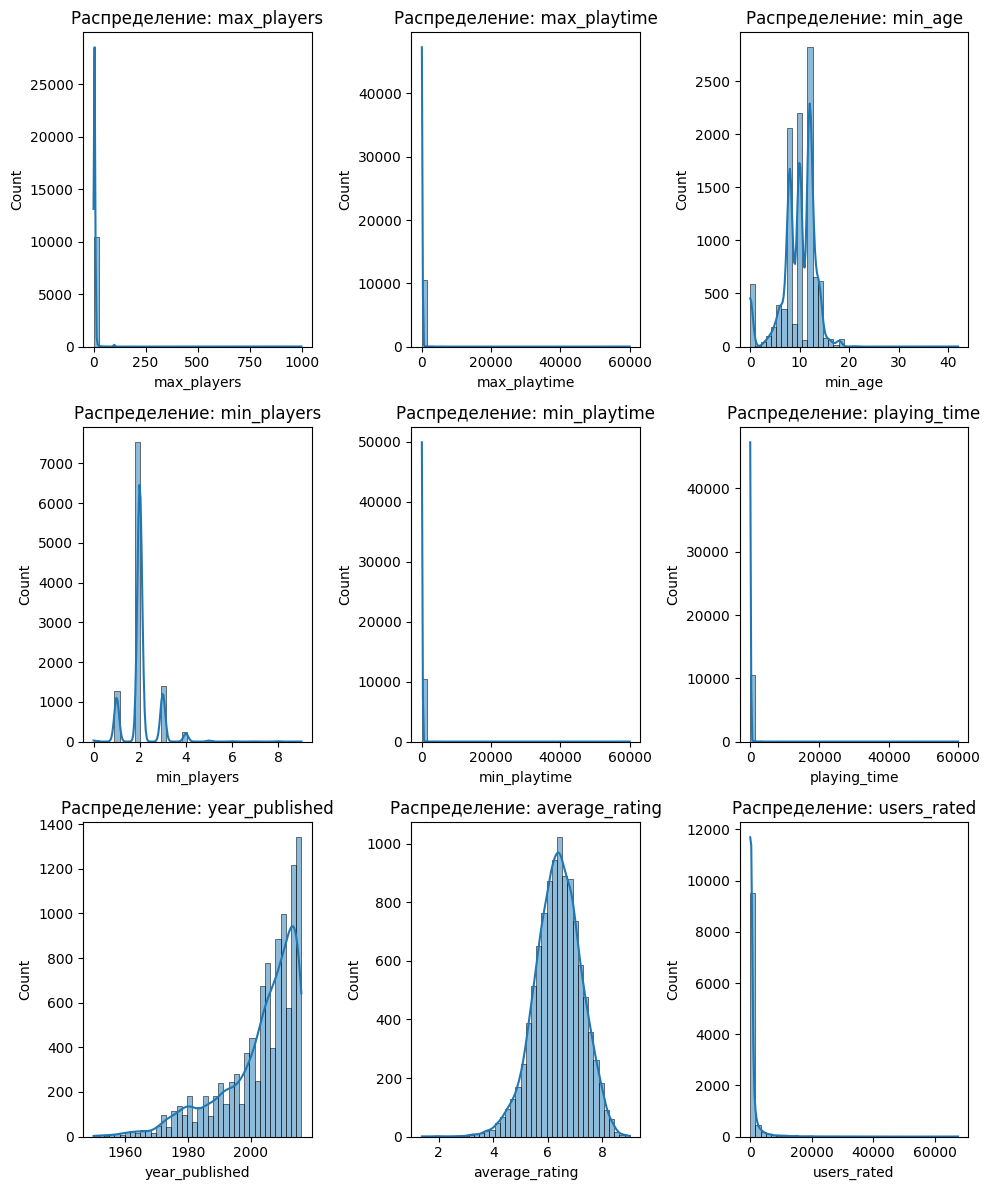

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(10, 12))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    sns.histplot(data=df_num, x=col, kde=True, ax=axes[idx], bins=40)
    axes[idx].set_title(f'Распределение: {col}')

plt.tight_layout()
plt.show()


Scatter plot помогает найти корреляции между переменными, например, между временем игры и рейтингом или популярностью.  

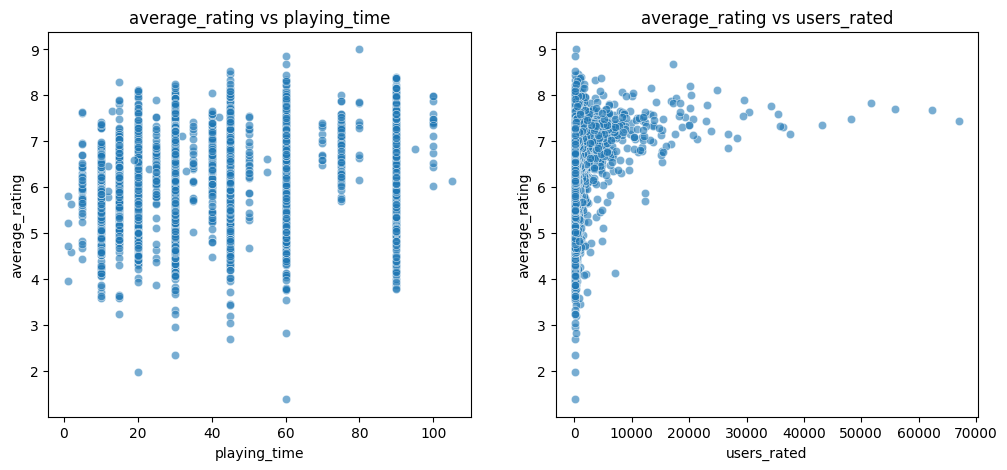

In [19]:

# Выбираем ключевые пары для scatter
pairs = [('playing_time', 'average_rating'), ('users_rated', 'average_rating')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.ravel()

for idx, (x, y) in enumerate(pairs):
    sns.scatterplot(data=df_final, x=x, y=y, ax=axes[idx], alpha=0.6)
    axes[idx].set_title(f'{y} vs {x}')




Box plot (ящик с усами) выявляет выбросы в числовых данных, показывая медиану, квартили и экстремальные значения.  

max_players       0
max_playtime      0
min_age           0
min_players       0
min_playtime      0
playing_time      0
year_published    0
average_rating    0
users_rated       0
dtype: int64


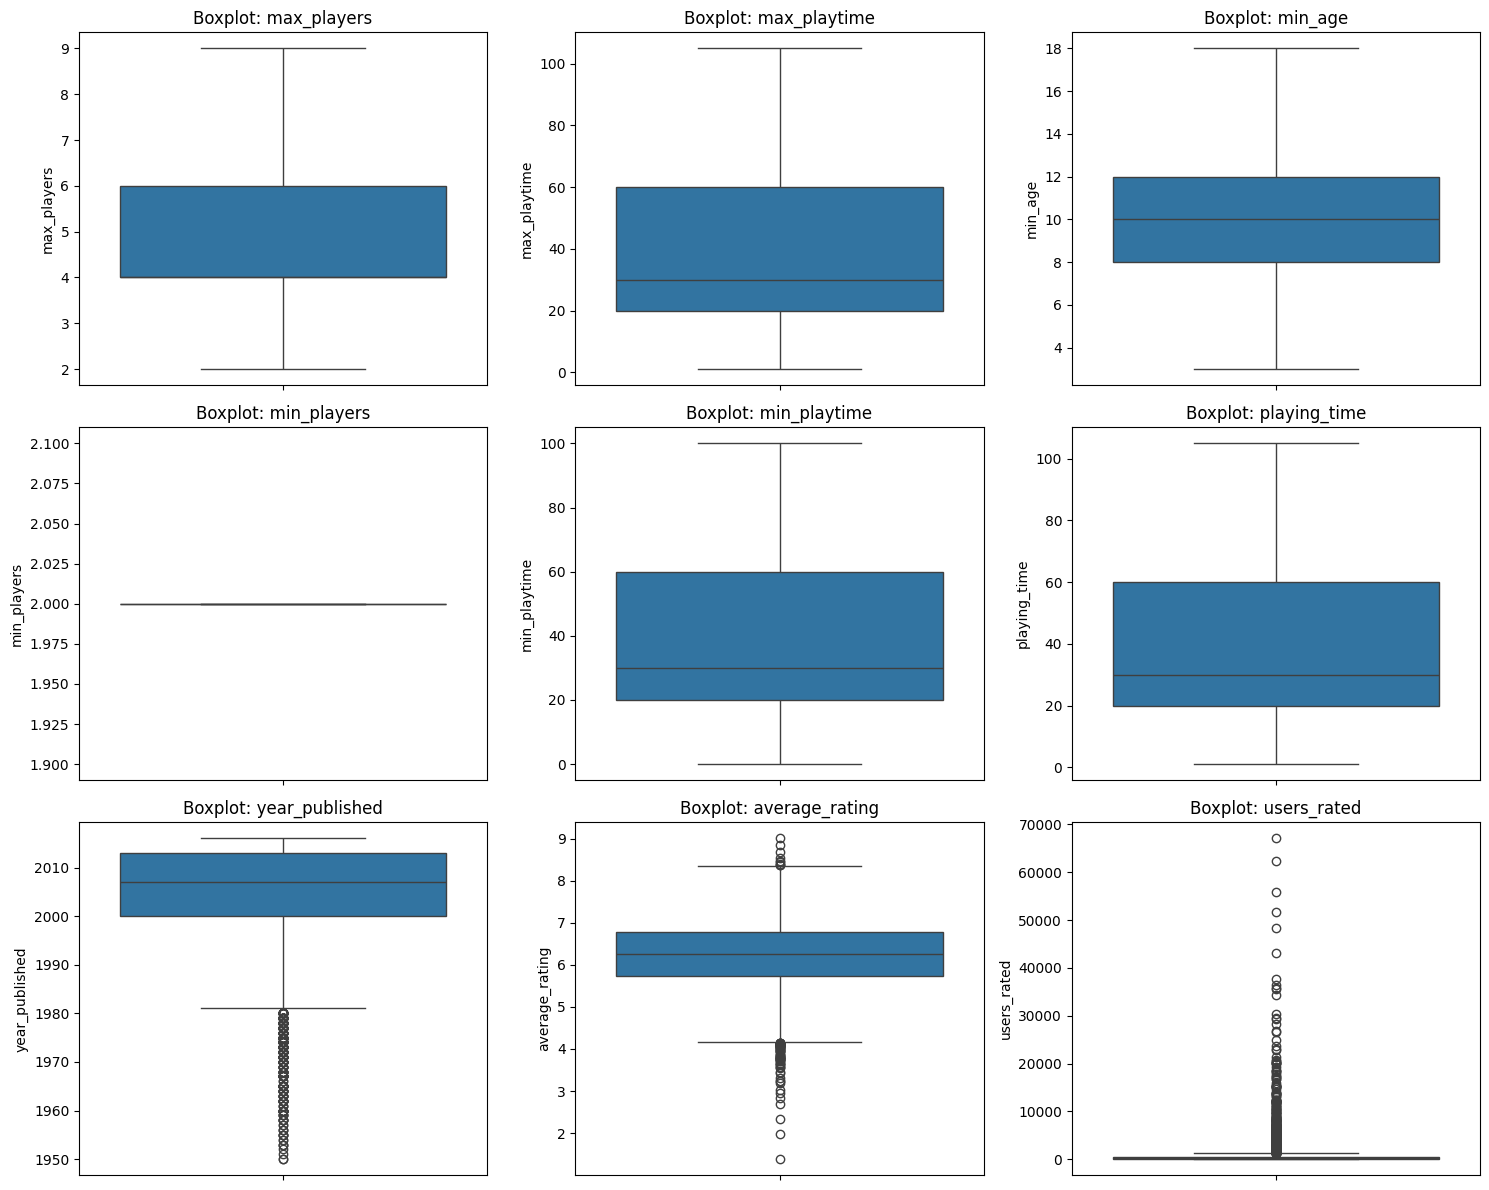

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

print(df_num.isnull().sum())

for idx, col in enumerate(num_cols):
    sns.boxplot(data=df_final, y=col, ax=axes[idx])
    axes[idx].set_title(f'Boxplot: {col}')

plt.tight_layout()

plt.show()


Подводя итог могу сказать что анализировать датасеты можно быстро с помощью удобных функций describe() и  info()   
Стратегии для работы с пропусками в таблице dropna() которая удаляет полностью строки с nAn и fillna которая заполняет их значениями медианой, средним, константой  
Так же можно получить более детальную статистику как прецентили, дисперсию, ассиметрию и эксцесс.  
Можно строить графики по своим данным гистограммы показывают распределение значений, boxplot еще более детальные данные 